In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             ConfusionMatrixDisplay, precision_recall_curve)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

os.chdir(r'C:\Users\bamla\OneDrive\Desktop\fraud-detection')
print("Libraries loaded!")

Libraries loaded!


In [2]:
fraud = pd.read_csv('data/processed/fraud_features.csv')
cc = pd.read_csv('data/processed/creditcard_features.csv')

print(f"Fraud_Data shape: {fraud.shape}")
print(f"CreditCard shape: {cc.shape}")
print(f"\nFraud_Data fraud rate: {fraud['class'].mean()*100:.2f}%")
print(f"CreditCard fraud rate: {cc['Class'].mean()*100:.4f}%")

Fraud_Data shape: (151112, 14)
CreditCard shape: (284807, 31)

Fraud_Data fraud rate: 9.36%
CreditCard fraud rate: 0.1727%


In [3]:
# Encode categoricals
fraud_model = fraud.copy()
cat_cols = ['source', 'browser', 'sex', 'country']
for col in cat_cols:
    le = LabelEncoder()
    fraud_model[col] = le.fit_transform(fraud_model[col].astype(str))

# Features and target
X_fraud = fraud_model.drop(columns=['user_id', 'class'])
y_fraud = fraud_model['class']

# Stratified split
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud
)

# Scale
scaler_f = StandardScaler()
X_train_f_scaled = scaler_f.fit_transform(X_train_f)
X_test_f_scaled = scaler_f.transform(X_test_f)

# SMOTE on training only
smote = SMOTE(random_state=42)
X_train_f_res, y_train_f_res = smote.fit_resample(X_train_f_scaled, y_train_f)

print(f"Before SMOTE: {pd.Series(y_train_f).value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_f_res).value_counts().to_dict()}")

Before SMOTE: {0: 109568, 1: 11321}
After SMOTE:  {0: 109568, 1: 109568}


In [4]:
X_cc = cc.drop(columns=['Class'])
y_cc = cc['Class']

X_train_cc, X_test_cc, y_train_cc, y_test_cc = train_test_split(
    X_cc, y_cc, test_size=0.2, random_state=42, stratify=y_cc
)

scaler_cc = StandardScaler()
X_train_cc_scaled = scaler_cc.fit_transform(X_train_cc)
X_test_cc_scaled = scaler_cc.transform(X_test_cc)

X_train_cc_res, y_train_cc_res = smote.fit_resample(X_train_cc_scaled, y_train_cc)

print(f"Before SMOTE: {pd.Series(y_train_cc).value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_cc_res).value_counts().to_dict()}")

Before SMOTE: {0: 227451, 1: 394}
After SMOTE:  {0: 227451, 1: 227451}


In [5]:
# Logistic Regression baseline
lr_f = LogisticRegression(max_iter=1000, random_state=42)
lr_f.fit(X_train_f_res, y_train_f_res)
lr_f_pred = lr_f.predict(X_test_f_scaled)
lr_f_prob = lr_f.predict_proba(X_test_f_scaled)[:,1]

# XGBoost
xgb_f = xgb.XGBClassifier(n_estimators=100, max_depth=5,
                            random_state=42, eval_metric='logloss')
xgb_f.fit(X_train_f_res, y_train_f_res)
xgb_f_pred = xgb_f.predict(X_test_f_scaled)
xgb_f_prob = xgb_f.predict_proba(X_test_f_scaled)[:,1]

print("=== Fraud_Data — Logistic Regression ===")
print(classification_report(y_test_f, lr_f_pred))
print(f"AUC-PR: {average_precision_score(y_test_f, lr_f_prob):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_f, lr_f_prob):.4f}")

print("\n=== Fraud_Data — XGBoost ===")
print(classification_report(y_test_f, xgb_f_pred))
print(f"AUC-PR: {average_precision_score(y_test_f, xgb_f_prob):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_f, xgb_f_prob):.4f}")

=== Fraud_Data — Logistic Regression ===
              precision    recall  f1-score   support

           0       0.97      0.94      0.95     27393
           1       0.53      0.70      0.60      2830

    accuracy                           0.91     30223
   macro avg       0.75      0.82      0.78     30223
weighted avg       0.93      0.91      0.92     30223

AUC-PR: 0.6547
ROC-AUC: 0.8336

=== Fraud_Data — XGBoost ===
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     27393
           1       0.99      0.53      0.69      2830

    accuracy                           0.96     30223
   macro avg       0.97      0.76      0.83     30223
weighted avg       0.96      0.96      0.95     30223

AUC-PR: 0.7022
ROC-AUC: 0.8301


In [6]:
lr_cc = LogisticRegression(max_iter=1000, random_state=42)
lr_cc.fit(X_train_cc_res, y_train_cc_res)
lr_cc_pred = lr_cc.predict(X_test_cc_scaled)
lr_cc_prob = lr_cc.predict_proba(X_test_cc_scaled)[:,1]

xgb_cc = xgb.XGBClassifier(n_estimators=100, max_depth=5,
                             random_state=42, eval_metric='logloss')
xgb_cc.fit(X_train_cc_res, y_train_cc_res)
xgb_cc_pred = xgb_cc.predict(X_test_cc_scaled)
xgb_cc_prob = xgb_cc.predict_proba(X_test_cc_scaled)[:,1]

print("=== CreditCard — Logistic Regression ===")
print(classification_report(y_test_cc, lr_cc_pred))
print(f"AUC-PR: {average_precision_score(y_test_cc, lr_cc_prob):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_cc, lr_cc_prob):.4f}")

print("\n=== CreditCard — XGBoost ===")
print(classification_report(y_test_cc, xgb_cc_pred))
print(f"AUC-PR: {average_precision_score(y_test_cc, xgb_cc_prob):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_cc, xgb_cc_prob):.4f}")

=== CreditCard — Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

AUC-PR: 0.7242
ROC-AUC: 0.9714

=== CreditCard — XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.64      0.87      0.74        98

    accuracy                           1.00     56962
   macro avg       0.82      0.93      0.87     56962
weighted avg       1.00      1.00      1.00     56962

AUC-PR: 0.8550
ROC-AUC: 0.9803


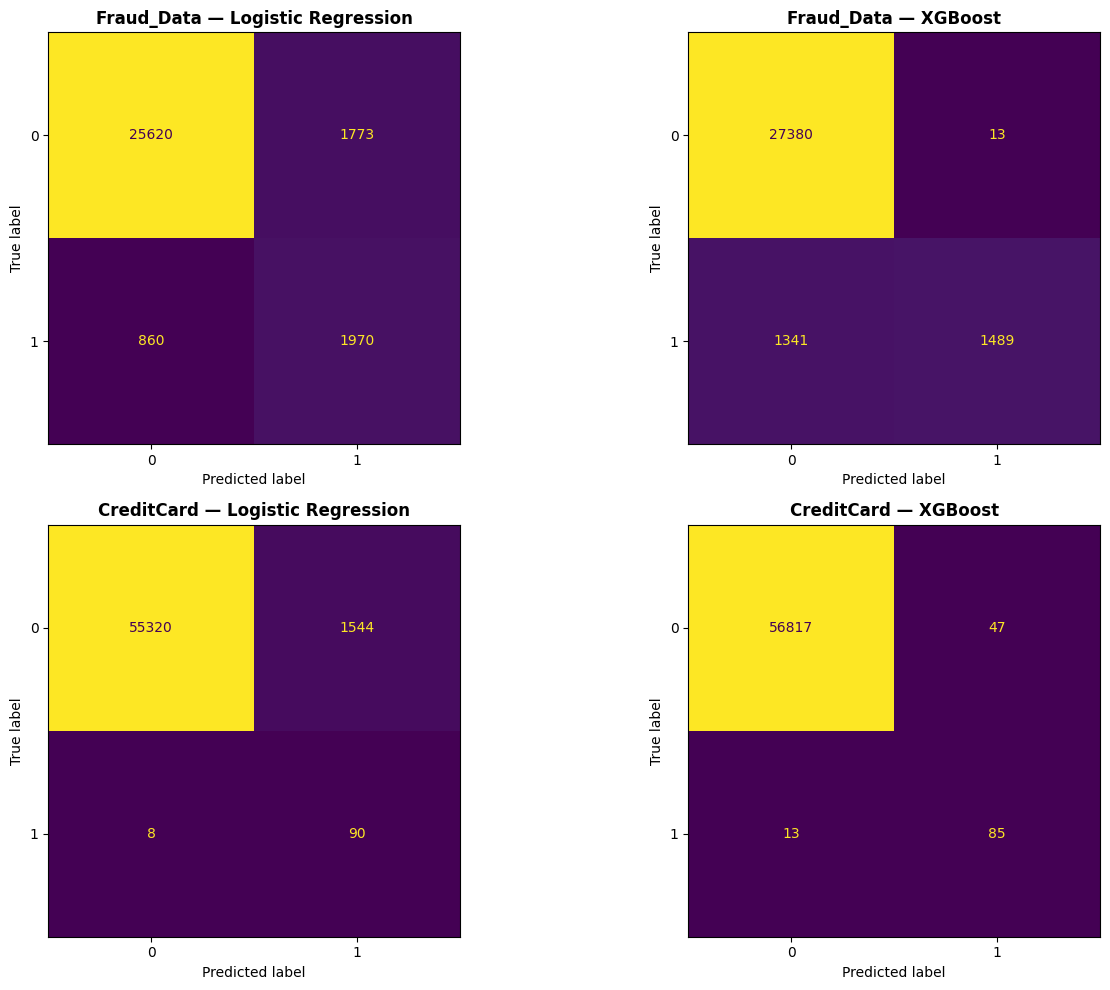

Confusion matrix plot saved!


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, model, preds, title in zip(
    axes.flatten(),
    [lr_f, xgb_f, lr_cc, xgb_cc],
    [lr_f_pred, xgb_f_pred, lr_cc_pred, xgb_cc_pred],
    ['Fraud_Data — Logistic Regression', 'Fraud_Data — XGBoost',
     'CreditCard — Logistic Regression', 'CreditCard — XGBoost']
):
    y_true = y_test_f if 'Fraud' in title else y_test_cc
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig('notebooks/model_confusion_matrices.png', dpi=150)
plt.show()
print("Confusion matrix plot saved!")

In [8]:
import joblib

os.makedirs('models', exist_ok=True)
joblib.dump(xgb_f, 'models/xgb_fraud.joblib')
joblib.dump(xgb_cc, 'models/xgb_creditcard.joblib')
joblib.dump(scaler_f, 'models/scaler_fraud.joblib')
joblib.dump(scaler_cc, 'models/scaler_creditcard.joblib')
print("Models saved!")

Models saved!
